# Exploratory Data Analysis (EDA)

## Objective 


The goal of this notebook is to explore the dataset, identify patterns, detect anomalies, understand feature distributions, and gather insights that will guide preprocessing and model development.


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Displa all columns
pd.set_option('display.max_columns', None)

In [104]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [105]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


### Duplicate Removal

The dataset contained duplicate observations. Since identical transactions may bias the model by over-representing certain patterns, duplicate rows were removed before conducting the exploratory analysis.

In [106]:
class_counts = df["Class"].value_counts()

class_counts

Class
0    283253
1       473
Name: count, dtype: int64

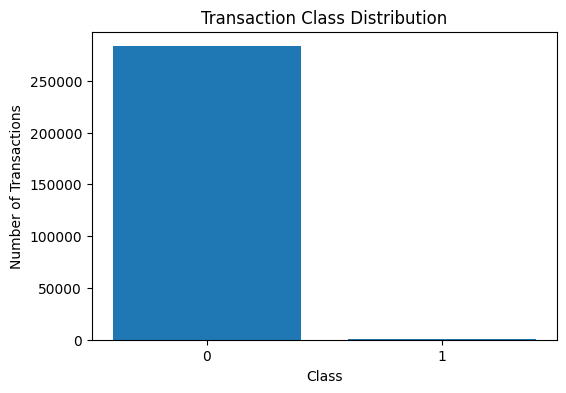

In [107]:
plt.figure(figsize=(6,4))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [108]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

class_percentage

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

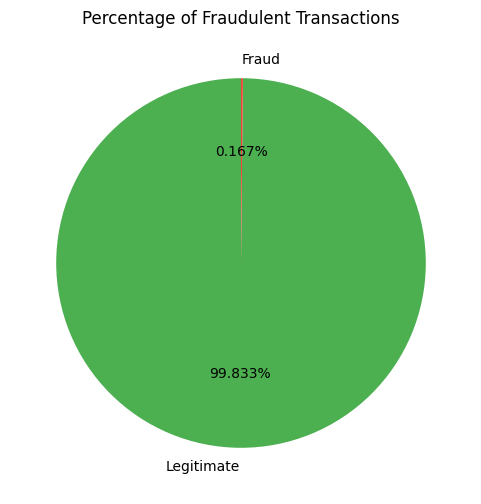

In [109]:
plt.figure(figsize=(6,6))

plt.pie(
    class_percentage,
    labels=["Legitimate", "Fraud"],
    colors=["#4CAF50", "#F44336"],
    autopct="%1.3f%%",
    startangle=90
)

plt.title("Percentage of Fraudulent Transactions")


plt.show()

## Interpretation of the Class Distribution

The bar chart shows that legitimate transactions (Class = 0) vastly outnumber fraudulent transactions (Class = 1). Fraudulent transactions account for only a very small percentage of the dataset, confirming that the data is **highly imbalanced**.

### Key Findings
- Legitimate transactions represent approximately **99.83%** of the dataset.
- Fraudulent transactions represent approximately **0.17%** of the dataset.

### Implications for Machine Learning
- The model may become biased toward predicting the majority class (legitimate transactions).
- Accuracy alone is not an appropriate evaluation metric because a model could achieve very high accuracy by predicting every transaction as legitimate.
- During model development, we will focus on evaluation metrics such as **Precision**, **Recall**, **F1-score**, and **ROC-AUC**.

## Transaction Amount Analysis

### Business Question

How are transaction amounts distributed?

Can transaction amount help distinguish fraudulent transactions from legitimate ones?

Are there outliers that could affect model training?

In [110]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

## Interpretation

The transaction amount is highly right-skewed. The average transaction amount (€88.47) is considerably higher than the median (€22.00), indicating that a relatively small number of high-value transactions increase the overall average.

Additionally, the maximum transaction amount (€25,691.16) is much larger than the 75th percentile (€77.51), suggesting the presence of extreme values (potential outliers).

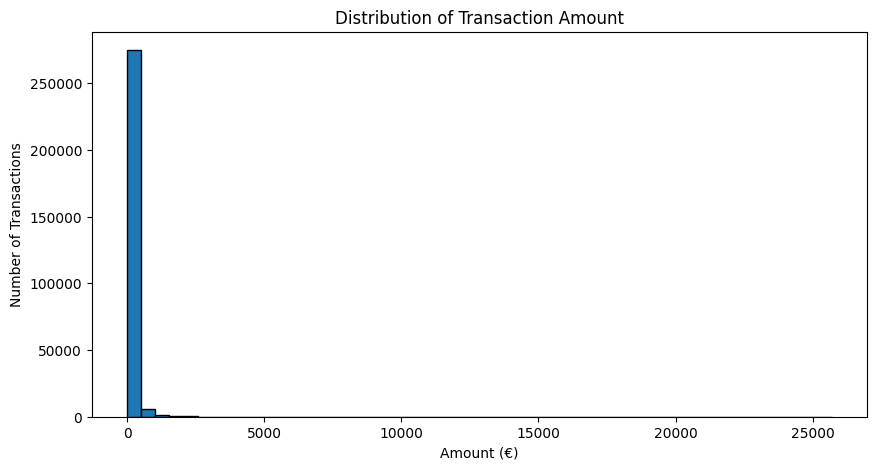

In [111]:
plt.figure(figsize=(10,5))

plt.hist(df["Amount"], bins=50, edgecolor="black")

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount (€)")
plt.ylabel("Number of Transactions")

plt.show()

## Interpretation

The histogram shows that most transactions are concentrated at low monetary values, while only a small number of transactions involve very large amounts.

The distribution is highly right-skewed, with a long tail extending toward higher transaction amounts. These extreme values compress the majority of the data into the left side of the histogram, making it difficult to observe the distribution of smaller transactions.

### Engineering Implications

- Most transactions involve relatively small amounts.
- The `Amount` feature contains high-value outliers.
- Feature scaling will be required before training several machine learning models.
- Additional visualizations focused on lower transaction amounts may provide better insight into the majority of transactions.

## Fraud vs Legitimate Transaction Amount

### Business Question

Do fraudulent transactions have different transaction amounts than legitimate transactions?

Understanding this relationship helps determine whether the `Amount` feature may be useful for fraud detection.

In [112]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


<Figure size 800x600 with 0 Axes>

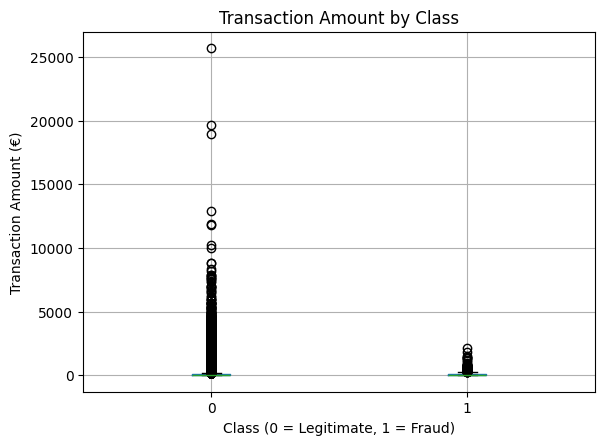

In [113]:
plt.figure(figsize=(8,6))

df.boxplot(column="Amount", by="Class")

plt.title("Transaction Amount by Class")
plt.suptitle("")   # removes the automatic pandas title
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount (€)")

plt.show()

<Figure size 800x600 with 0 Axes>

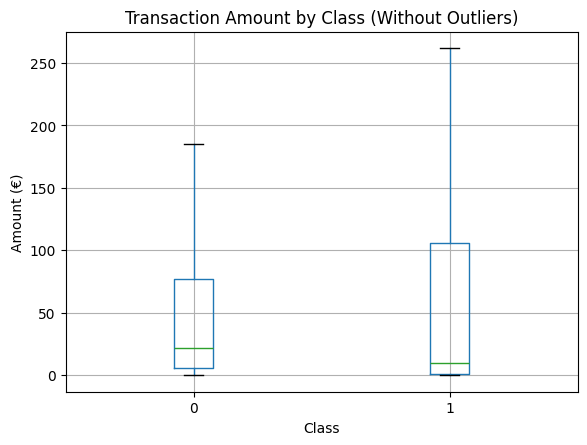

In [114]:
plt.figure(figsize=(8,6))

df.boxplot(
    column="Amount",
    by="Class",
    showfliers=False
)

plt.title("Transaction Amount by Class (Without Outliers)")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Amount (€)")

plt.show()

## Interpretation

Removing outliers makes it easier to compare the typical transaction amounts between legitimate and fraudulent transactions.

Fraudulent transactions have a lower median amount than legitimate transactions, indicating that many fraud cases involve relatively small purchases.

However, the fraud class shows a wider spread and includes higher transaction amounts within its normal range. Despite these differences, the two distributions overlap considerably.

## Engineering Implications

- The `Amount` feature provides useful information but cannot distinguish fraud by itself.
- The feature should be retained and scaled during preprocessing.
- Effective fraud detection will require combining `Amount` with the other available features.

## Time Feature Analysis

### Business Question

What does the `Time` feature represent?

Does the occurrence of fraudulent transactions vary over the two-day observation period?

In [115]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

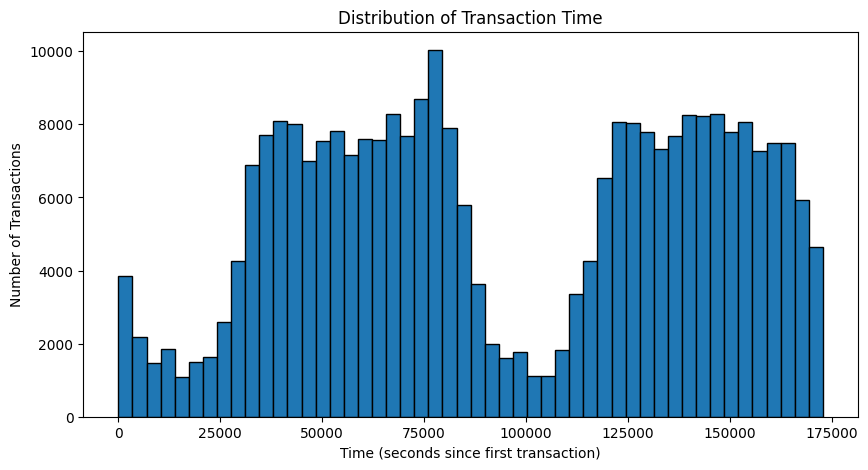

In [116]:
plt.figure(figsize=(10,5))

plt.hist(df["Time"], bins=50, edgecolor="black")

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Number of Transactions")

plt.show()

## Interpretation

The distribution of transaction times is not uniform across the two-day observation period. Instead, transaction activity follows a repeating pattern with periods of high and low activity.

This likely reflects normal customer behavior, where transaction volume changes throughout the day (e.g., lower activity during nighttime and higher activity during daytime).

### Engineering Implications

- The `Time` feature contains temporal information that may help distinguish transaction patterns.
- Since `Time` has a much larger numerical range than the PCA features, it should be scaled during preprocessing.
- Further analysis is needed to determine whether fraudulent transactions occur more frequently during specific periods.

### Initial Comparison

An overlaid histogram using raw counts was created to compare transaction times.

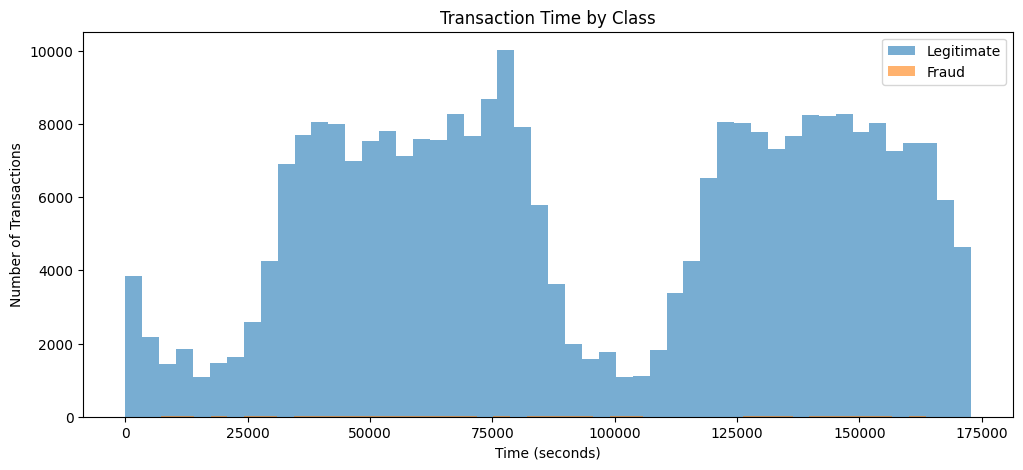

In [117]:
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

plt.figure(figsize=(12,5))

plt.hist(
    legit["Time"],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    fraud["Time"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.title("Transaction Time by Class")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Transactions")

plt.legend()

plt.show()

Observation:

Because the dataset is highly imbalanced, legitimate transactions dominate the visualization, making the fraud distribution difficult to interpret.

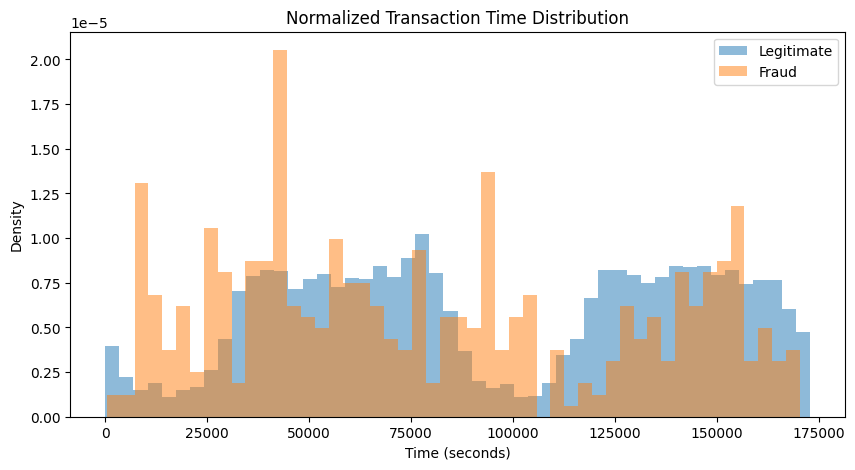

In [118]:
plt.figure(figsize=(10,5))

plt.hist(
    legit["Time"],
    bins=50,
    density=True,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    fraud["Time"],
    bins=50,
    density=True,
    alpha=0.5,
    label="Fraud"
)

plt.legend()

plt.title("Normalized Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")

plt.show()

## Interpretation

After normalizing the histogram, the temporal distributions of legitimate and fraudulent transactions can be compared fairly despite the class imbalance.

Both classes follow similar overall time patterns throughout the two-day observation period, with transaction activity increasing and decreasing in similar intervals.

Although the fraud distribution appears slightly more irregular, this is likely influenced by the much smaller number of fraud samples.

### Engineering Implications

- The `Time` feature alone is unlikely to distinguish fraudulent transactions because the two distributions overlap considerably.
- However, `Time` may still contribute useful information when combined with other features.
- The feature will be retained and scaled during preprocessing.

# Correlation Analysis

## Business Question

Which features have the strongest positive and negative relationship with fraudulent transactions?

Understanding these relationships helps identify potentially informative features for the machine learning model.

In [119]:
correlation_matrix = df.corr()

correlation_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,0.031068,-0.248536,0.125500,-0.065958,-0.100316,-0.184392,0.011286,-0.073819,0.090305,0.029537,-0.051022,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,0.000815,0.001028,-0.001524,-0.000568,-0.002663,-0.000602,-0.003345,-0.003491,-0.003535,0.000919,-0.001393,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,0.000620,-0.000633,0.002266,0.000680,0.002711,0.001538,0.004013,0.003244,0.002477,-0.000358,-0.001287,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,-0.009632,0.002339,-0.005900,0.000113,-0.003027,-0.001230,-0.004430,-0.008159,-0.003495,-0.000016,-0.002269,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,0.002753,-0.001223,0.003366,0.000177,0.002801,0.000572,0.003346,0.003655,0.002325,-0.000560,0.000318,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326


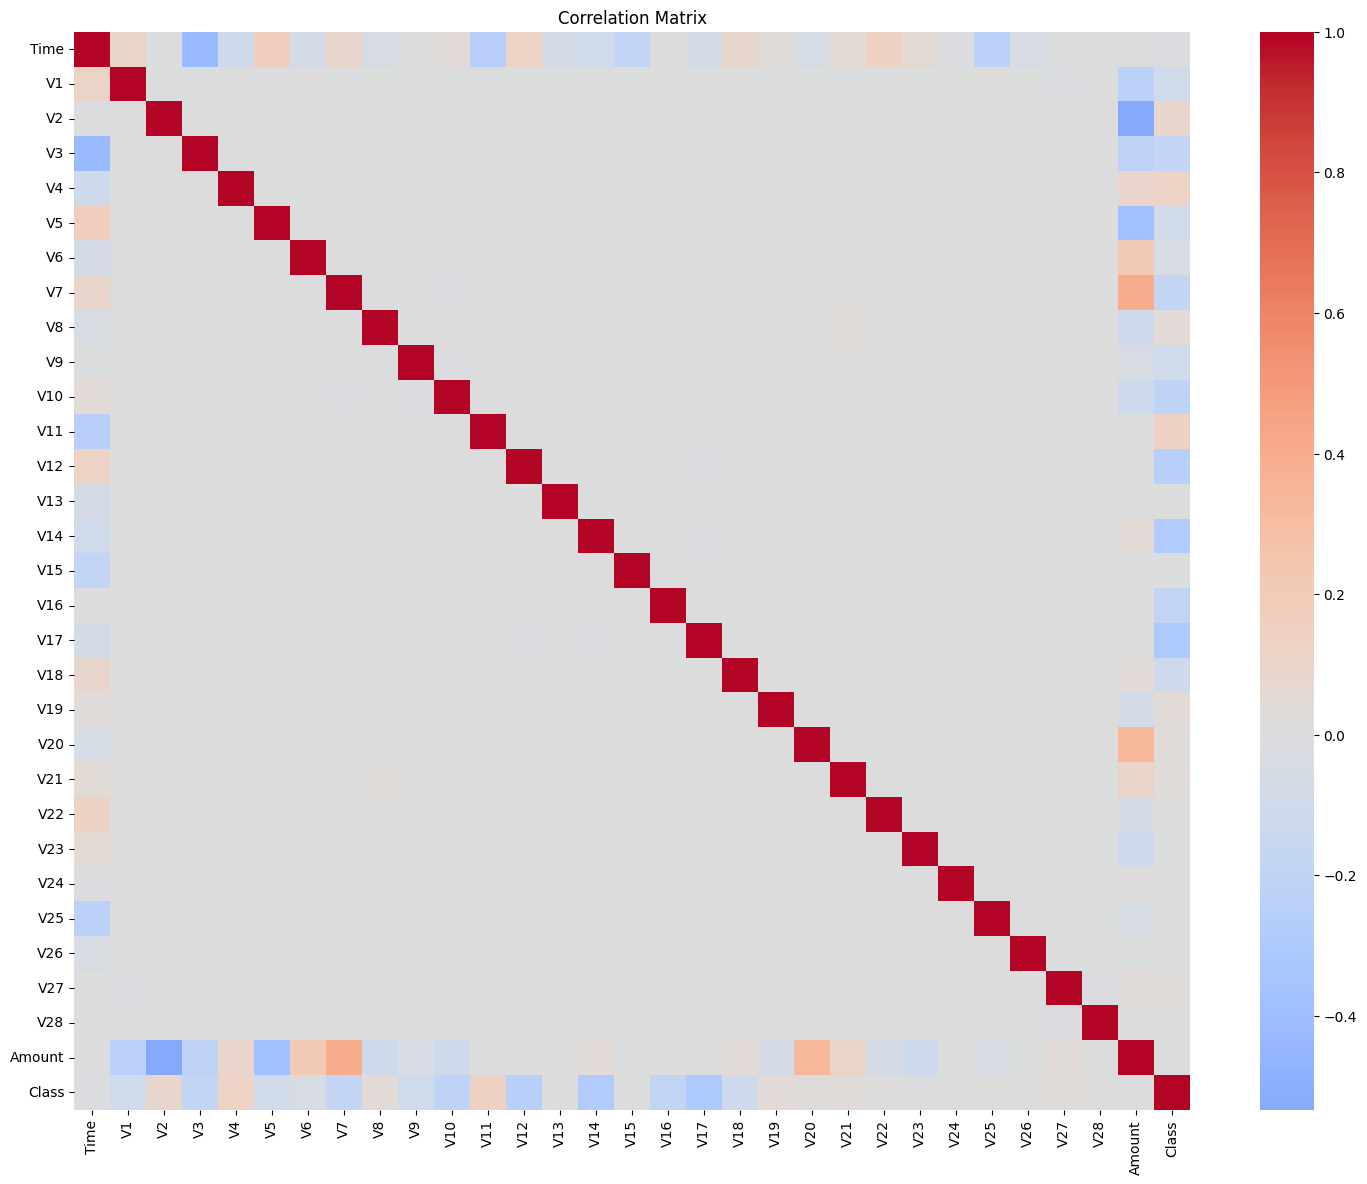

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [121]:
class_correlation = correlation_matrix["Class"].sort_values()

class_correlation

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64

## Interpretation

The correlation analysis shows that several PCA-derived features have moderate relationships with the target variable (`Class`).

The strongest negative correlations are observed for **V17, V14, V12, V10, and V16**, suggesting these features contain useful information for distinguishing fraudulent transactions.

In contrast, features such as **Time**, **Amount**, **V13**, **V23**, and **V24** exhibit correlations close to zero, indicating weak linear relationships with the target.

However, low correlation does **not** imply that a feature is unimportant. Machine learning models can capture complex interactions between multiple features, allowing variables with weak individual correlations to contribute to predictive performance.

### Engineering Implications

- The dataset does not contain a single dominant predictor of fraud.
- Fraud detection will likely depend on combining information from multiple features.
- All features will be retained for model training at this stage.

# EDA Summary

## Key Findings

- The dataset contains **283,726 transactions** after removing duplicate records.
- Fraudulent transactions are extremely rare, representing only **0.166%** of the dataset, indicating a severe class imbalance.
- The dataset contains no missing values, reducing the need for data cleaning.
- The `Amount` feature is highly right-skewed, with most transactions involving relatively small amounts.
- Fraudulent transactions generally have a lower median amount than legitimate transactions, although the distributions overlap considerably.
- Transaction activity follows a repeating temporal pattern over the two-day observation period, likely reflecting daily customer behavior.
- The `Time` feature alone does not clearly distinguish fraudulent transactions but may provide useful information when combined with other features.
- Correlation analysis shows that features such as **V17, V14, V12, V10, and V16** have the strongest relationships with the target variable.
- No single feature strongly predicts fraud, suggesting that the machine learning model must learn from the interaction of multiple features.

## Next Steps

The next phase of the project will focus on:

1. Train-test splitting.
2. Scaling the `Time` and `Amount` features.
3. Handling class imbalance using appropriate techniques.
4. Training baseline machine learning models.
5. Evaluating model performance using fraud-focused metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC.